# Visualization Insights
Dedicated EDA and model evaluation suite for the Bharat Bytes Zerve AI Datathon.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

# Premium dark-mode aesthetic (Zerve design system)
ZERVE_BG = '#1D1D20'
ZERVE_TEXT = '#fbfbff'
ZERVE_SECONDARY = '#909094'
ZERVE_COLORS = ['#A1C9F4', '#FFB482', '#8DE5A1', '#FF9F9B', '#D0BBFF', '#1F77B4', '#9467BD', '#8C564B']
ZERVE_HIGHLIGHT = '#ffd400'
ZERVE_SUCCESS = '#17b26a'
ZERVE_WARNING = '#f04438'

# Set style for matplotlib
plt.rcParams['figure.facecolor'] = ZERVE_BG
plt.rcParams['axes.facecolor'] = ZERVE_BG
plt.rcParams['axes.edgecolor'] = ZERVE_SECONDARY
plt.rcParams['axes.labelcolor'] = ZERVE_TEXT
plt.rcParams['text.color'] = ZERVE_TEXT
plt.rcParams['xtick.color'] = ZERVE_TEXT
plt.rcParams['ytick.color'] = ZERVE_TEXT
plt.rcParams['legend.facecolor'] = ZERVE_BG
plt.rcParams['legend.edgecolor'] = ZERVE_SECONDARY

# Set style for seaborn
sns.set_style({
    'axes.facecolor': ZERVE_BG,
    'figure.facecolor': ZERVE_BG,
    'text.color': ZERVE_TEXT,
    'axes.labelcolor': ZERVE_TEXT,
    'xtick.color': ZERVE_TEXT,
    'ytick.color': ZERVE_TEXT,
    'grid.color': ZERVE_SECONDARY,
    'axes.edgecolor': ZERVE_SECONDARY
})

## 1. Load Data and Replicate Split
Load `training_data.csv` and replicate the 60/20/20 (Train/Val/Holdout) split to ensure consistency with `Final_Model.py`.

In [2]:
RANDOM_SEED = 42
TARGET_COL = 'target'
ID_COL = 'id'

try:
    train_raw = pd.read_csv('training_data.csv')
    print(f"Data loaded successfully. Shape: {train_raw.shape}")
except FileNotFoundError:
    print("Error: 'training_data.csv' not found. Please ensure it's in the same directory.")

if 'train_raw' in locals():
    # Separate features and target
    X_full = train_raw.drop(columns=[TARGET_COL])
    y_full = train_raw[TARGET_COL]

    cat_cols_detected = X_full.select_dtypes(include=['object', 'category']).columns.tolist()
    cat_cols_filtered = [c for c in cat_cols_detected if c != ID_COL]

    # Drop ID from features
    X_processed = X_full.drop(columns=[ID_COL], errors='ignore')

    # First split: 80% (temp) and 20% (holdout)
    X_temp, X_holdout, y_temp, y_holdout = train_test_split(
        X_processed, y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=RANDOM_SEED
    )

    # Second split: 75% of temp (train) and 25% of temp (valid) (60/20/20 overall)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp, y_temp,
        test_size=0.25,
        stratify=y_temp,
        random_state=RANDOM_SEED
    )

    print(f"Train-validation split (60/20/20) complete:")
    print(f"  Train: {X_train.shape[0]:,} samples")
    print(f"  Valid: {X_valid.shape[0]:,} samples")
    print(f"  Holdout: {X_holdout.shape[0]:,} samples")

Data loaded successfully. Shape: (476169, 52)


C:\Users\harsh\AppData\Local\Temp\ipykernel_16668\2148914978.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_detected = X_full.select_dtypes(include=['object', 'category']).columns.tolist()


Train-validation split (60/20/20) complete:
  Train: 285,701 samples
  Valid: 95,234 samples
  Holdout: 95,234 samples


## 2. Target Distribution
A stylized bar chart highlighting the severe 26.4:1 class imbalance.

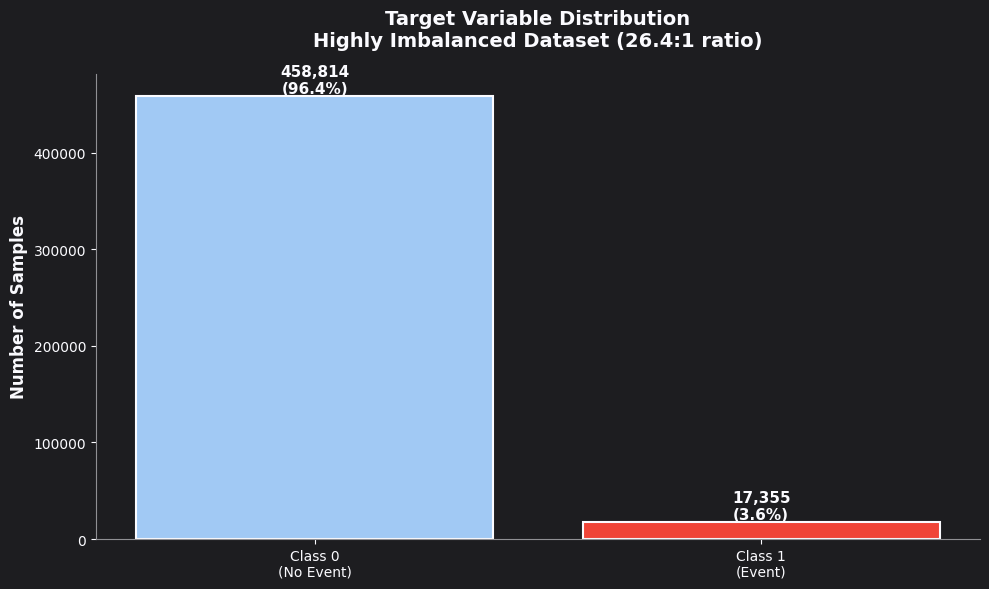

In [3]:
if 'y_full' in locals():
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    _counts = y_full.value_counts().sort_index()
    _labels = ['Class 0\n(No Event)', 'Class 1\n(Event)']
    bars = ax.bar(_labels, _counts, color=[ZERVE_COLORS[0], ZERVE_WARNING], edgecolor=ZERVE_TEXT, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/len(y_full)*100:.1f}%)',
                ha='center', va='bottom', color=ZERVE_TEXT, fontsize=11, fontweight='bold')

    ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
    ax.set_title('Target Variable Distribution\nHighly Imbalanced Dataset (26.4:1 ratio)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

## 3. Missing Value Matrix
A heatmap showing missing data density across features.

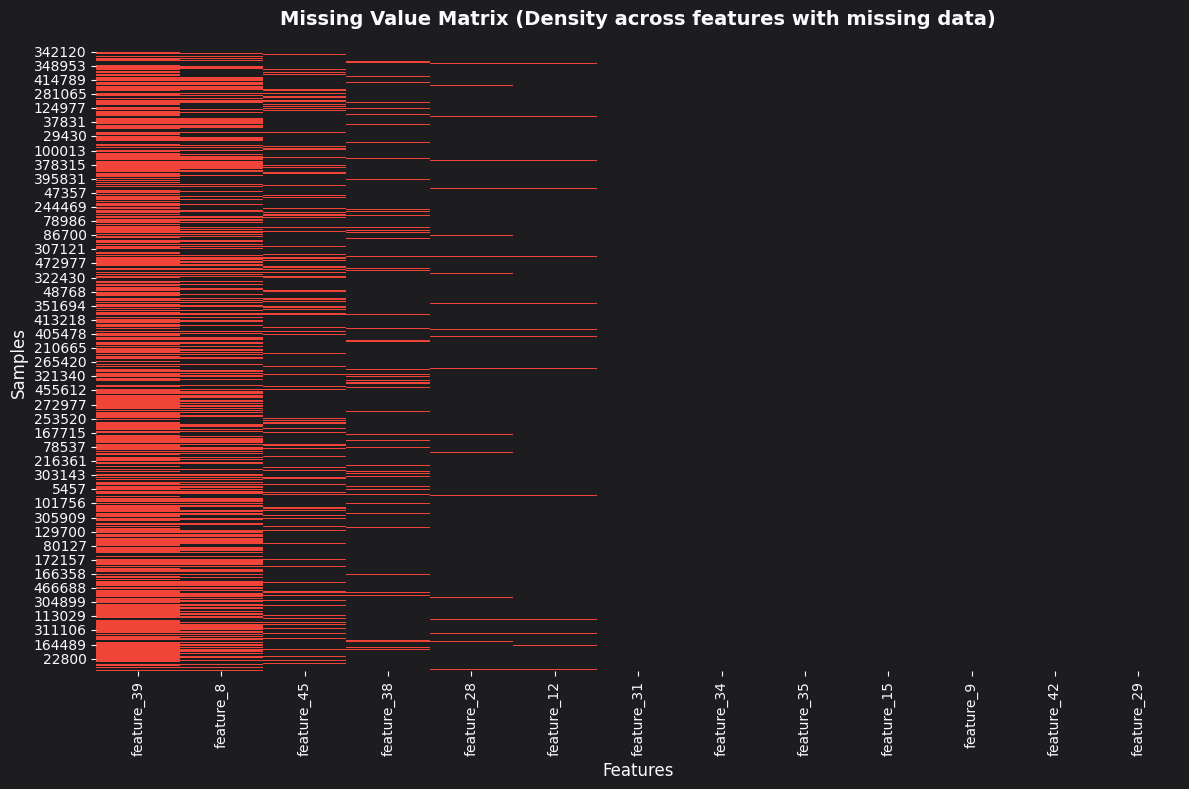

In [4]:
if 'train_raw' in locals():
    plt.figure(figsize=(12, 8))
    sample_data = train_raw.sample(min(10000, len(train_raw))) if len(train_raw) > 10000 else train_raw
    feature_cols = [col for col in train_raw.columns if col not in ['id', 'target']]
    
    missing_pct = (train_raw[feature_cols].isnull().sum() / len(train_raw)) * 100
    features_with_missing = missing_pct[missing_pct > 0].sort_values(ascending=False)
    
    if len(features_with_missing) > 0:
        sns.heatmap(sample_data[features_with_missing.index].isnull(), cbar=False, cmap=[ZERVE_BG, ZERVE_WARNING])
        plt.title('Missing Value Matrix (Density across features with missing data)', fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Features', fontsize=12)
        plt.ylabel('Samples', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values found in the dataset.")

## 4. Feature Correlations
Horizontal bar chart of the top 20 numerical features Pearson-correlated with the target.

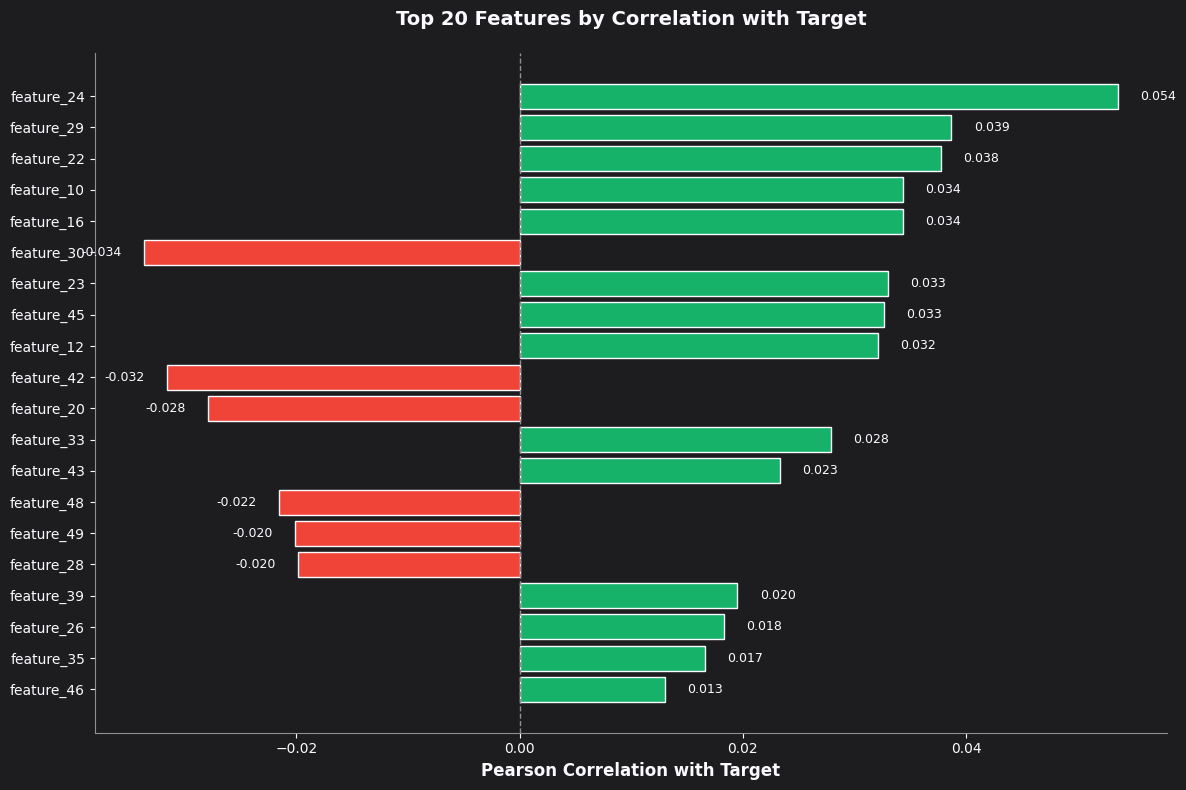

In [5]:
if 'train_raw' in locals():
    plt.figure(figsize=(12, 8))
    _feature_list = [col for col in train_raw.columns if col not in ['id', 'target']]
    
    _correlations = []
    num_cols = train_raw[_feature_list].select_dtypes(include=[np.number]).columns
    for feat in num_cols:
        _clean_data = train_raw[[feat, 'target']].dropna()
        if len(_clean_data) > 0 and _clean_data[feat].nunique() > 1:
            _corr, _ = pearsonr(_clean_data[feat], _clean_data['target'])
            _correlations.append((_corr, feat))

    _correlations.sort(key=lambda x: abs(x[0]), reverse=True)
    _top_corr = _correlations[:20]
    _corr_values = [c[0] for c in _top_corr]
    _corr_names = [c[1] for c in _top_corr]

    ax = plt.gca()
    _colors = [ZERVE_SUCCESS if c > 0 else ZERVE_WARNING for c in _corr_values]
    bars = ax.barh(range(len(_corr_values)), _corr_values, color=_colors, edgecolor=ZERVE_TEXT, linewidth=1)
    ax.set_yticks(range(len(_corr_names)))
    ax.set_yticklabels(_corr_names, fontsize=10)
    ax.set_xlabel('Pearson Correlation with Target', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Features by Correlation with Target', fontsize=14, fontweight='bold', pad=20)
    ax.axvline(x=0, color=ZERVE_SECONDARY, linestyle='--', linewidth=1)

    for i, val in enumerate(_corr_values):
        ax.text(val + (0.002 if val > 0 else -0.002), i, f'{val:.3f}', 
                va='center', ha='left' if val > 0 else 'right', color=ZERVE_TEXT, fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Feature Distributions
Overlaid KDE plots for top features, stratified by the target class.

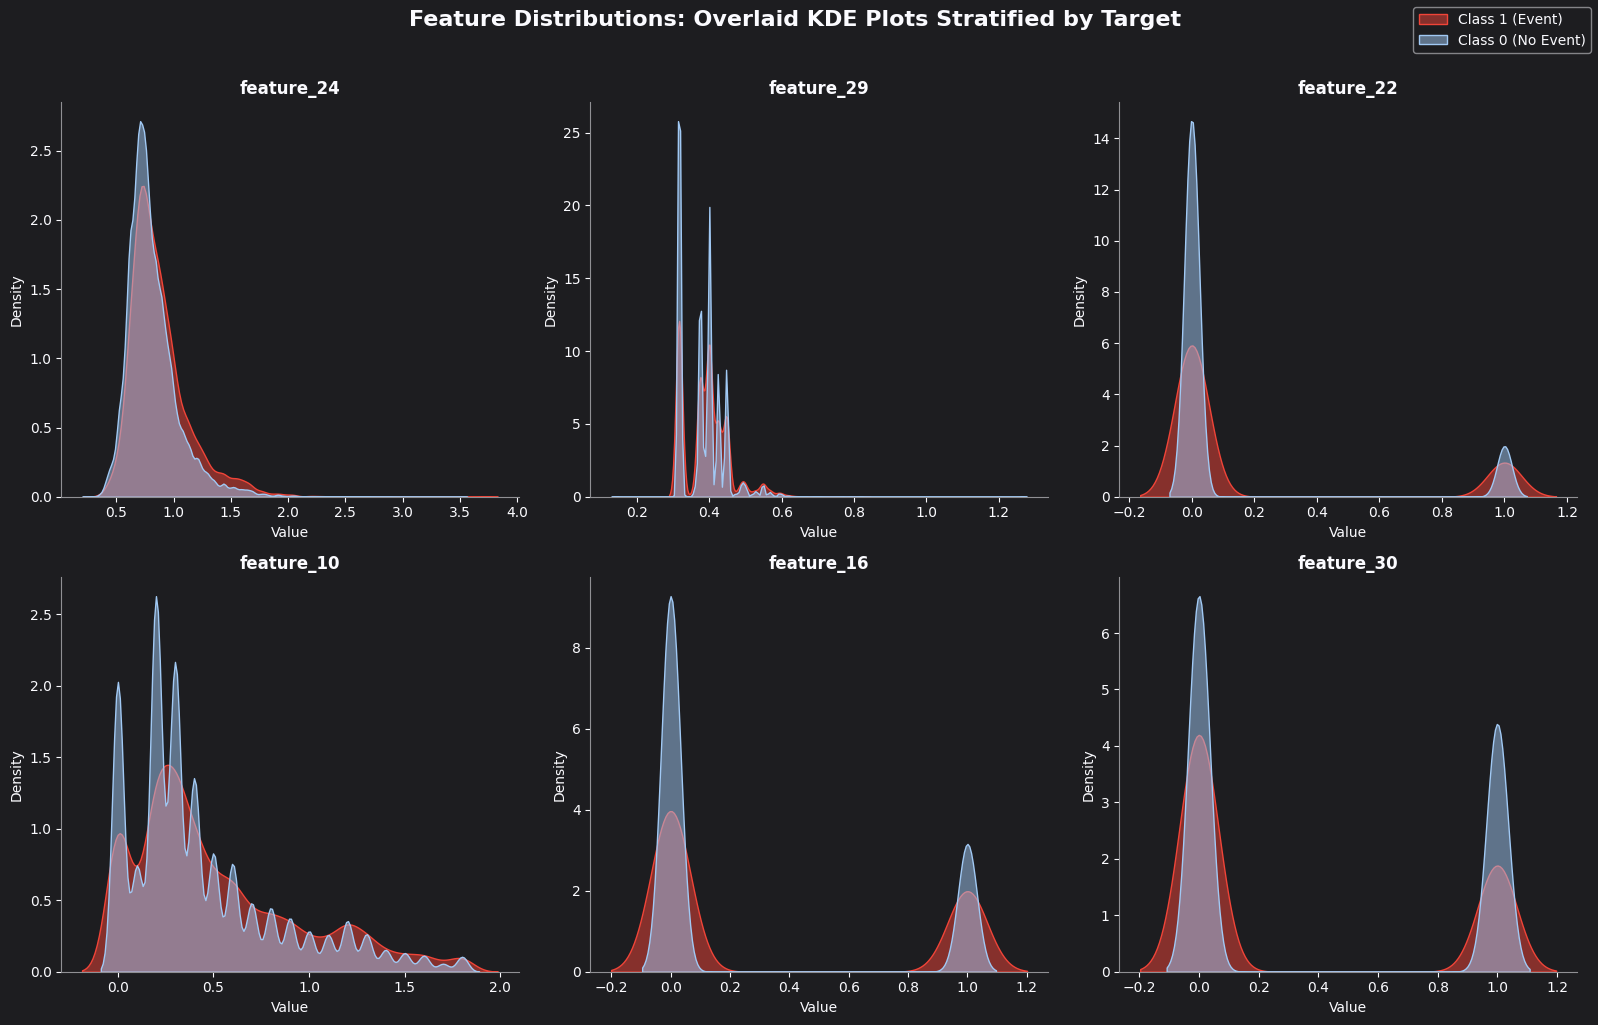

In [6]:
if 'train_raw' in locals() and len(_top_corr) > 0:
    _key_features = [feat[1] for feat in _top_corr[:6]]
    
    feature_dist_fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, feat in enumerate(_key_features):
        ax = axes[idx]
        
        sns.kdeplot(data=train_raw, x=feat, hue='target', fill=True, common_norm=False, 
                    palette=[ZERVE_COLORS[0], ZERVE_WARNING], alpha=0.5, ax=ax, legend=False)
        
        ax.set_title(feat, fontsize=12, fontweight='bold')
        ax.set_xlabel('Value', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    feature_dist_fig.legend(labels=['Class 1 (Event)', 'Class 0 (No Event)'], loc='upper right', framealpha=0.9)
    plt.suptitle('Feature Distributions: Overlaid KDE Plots Stratified by Target', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. CatBoost Performance
Parse `catboost_info/learn_error.tsv` and `test_error.tsv` to plot learning curves for AUC and Logloss.

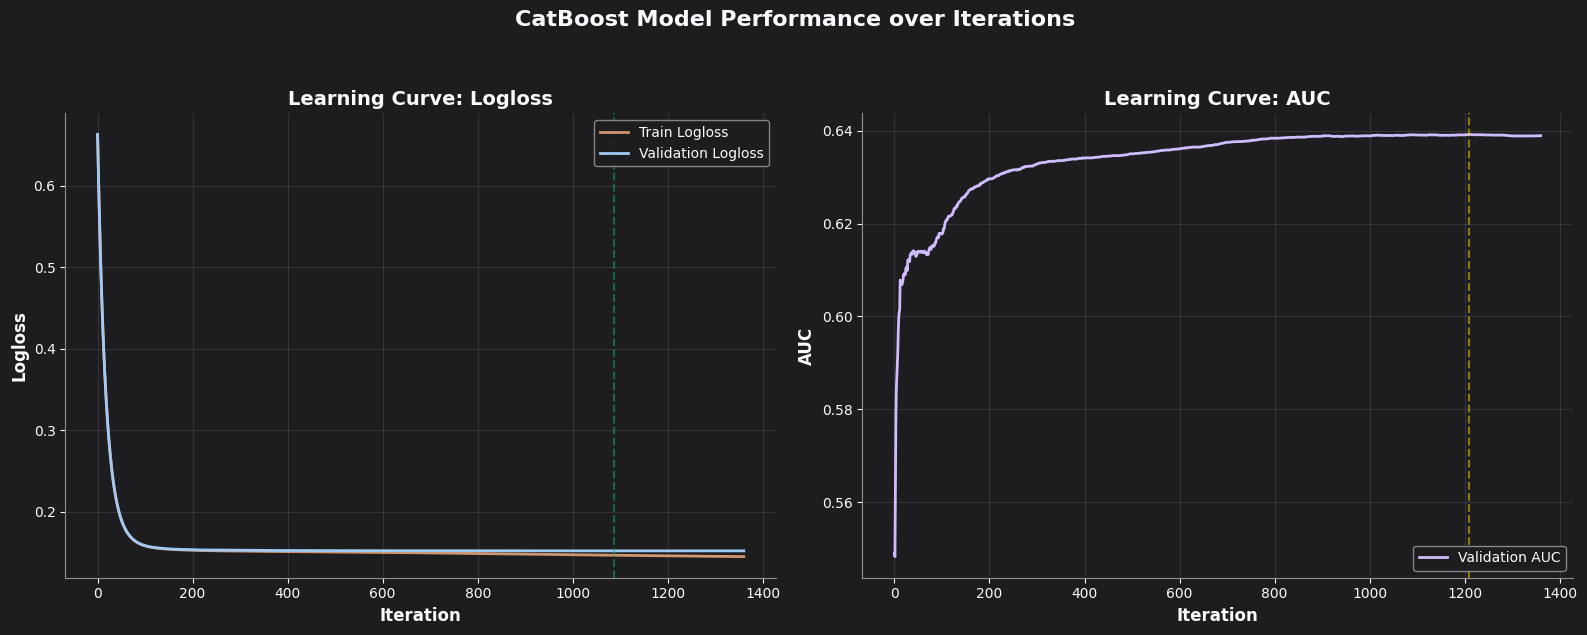

In [7]:
import os

learn_error_path = 'catboost_info/learn_error.tsv'
test_error_path = 'catboost_info/test_error.tsv'

if os.path.exists(learn_error_path) and os.path.exists(test_error_path):
    learn_errors = pd.read_csv(learn_error_path, sep='\t')
    test_errors = pd.read_csv(test_error_path, sep='\t')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Logloss Curve
    if 'Logloss' in learn_errors.columns and 'Logloss' in test_errors.columns:
        ax1.plot(learn_errors['iter'], learn_errors['Logloss'], color=ZERVE_COLORS[1], linewidth=2, label='Train Logloss', alpha=0.8)
        ax1.plot(test_errors['iter'], test_errors['Logloss'], color=ZERVE_COLORS[0], linewidth=2, label='Validation Logloss')
        ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Logloss', fontsize=12, fontweight='bold')
        ax1.set_title('Learning Curve: Logloss', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper right', framealpha=0.9)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.2, color=ZERVE_SECONDARY)
        
        best_iter_logloss = test_errors['Logloss'].idxmin()
        ax1.axvline(x=best_iter_logloss, color=ZERVE_SUCCESS, linestyle='--', alpha=0.5, label='Best Logloss')

    # AUC Curve
    if 'AUC' in test_errors.columns:
        ax2.plot(test_errors['iter'], test_errors['AUC'], color=ZERVE_COLORS[4], linewidth=2, label='Validation AUC')
        ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
        ax2.set_ylabel('AUC', fontsize=12, fontweight='bold')
        ax2.set_title('Learning Curve: AUC', fontsize=14, fontweight='bold')
        ax2.legend(loc='lower right', framealpha=0.9)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2, color=ZERVE_SECONDARY)
        
        best_iter_auc = test_errors['AUC'].idxmax()
        ax2.axvline(x=best_iter_auc, color=ZERVE_HIGHLIGHT, linestyle='--', alpha=0.5, label='Best AUC')
        
    plt.suptitle('CatBoost Model Performance over Iterations', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("CatBoost logs not found in 'catboost_info/' directory. Please ensure the model has been trained.")